# Run this first !
Ensures correct libraries and imports data

In [1]:
# Run this first !
# project setup — run first, do not edit except NAME
NAME = "rachel" # <<< your name

import sys, subprocess, pathlib
IN_COLAB = "google.colab" in sys.modules
REPO = "boe-financial-analysis"

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
    if not pathlib.Path(f"/content/{REPO}").exists():
        subprocess.run(["git", "clone", "-q",
                        f"https://github.com/maybebool/{REPO}.git",
                        f"/content/{REPO}"], check=True)
    ROOT = pathlib.Path(f"/content/{REPO}")
    DATA = pathlib.Path("/content/drive/MyDrive/boe-data")
else:
    ROOT = pathlib.Path.cwd()
    while not (ROOT / "requirements.txt").exists() and ROOT != ROOT.parent:
        ROOT = ROOT.parent
    DATA = ROOT / "data"

sys.path.insert(0, str(ROOT))
subprocess.run(["git", "-C", str(ROOT), "fetch", "-q", "origin"], check=False)
subprocess.run(["git", "-C", str(ROOT), "merge", "-q", "origin/main", "-m", "sync"],
               check=False)
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r",
                str(ROOT / "requirements.txt")], check=True)

from notebooks.env_cell import verify, check_python
check_python()
try:
    verify(ROOT)
except RuntimeError as e:
    print(e)
    print("\n Runtime -> Restart session, then run this cell again.")
    raise

import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from src import loading

print(f"ok  python {sys.version.split()[0]}  pandas {pd.__version__}  data {DATA}")
print(loading.exports(DATA))
print(loading.files(DATA))

# Updated with new data as of 2026-09-30
utt = loading.load(DATA, "all_utterances.csv", "2026-09-30")
sent = loading.load(DATA, "all_sentences.csv", "2026-09-30")
met = loading.load(DATA, "all_metrics.csv", "2026-09-30")

print(utt.shape, sent.shape, met.shape)
sent.head()
data=sent.copy()

ok  python 3.12.13  pandas 2.2.3  data /Users/rdrobinson/Cambridge/boe-financial-analysis/data
['2026-09-13', '2026-09-23', '2026-09-30']
['all_metrics.csv', 'all_sentences.csv', 'all_utterances.csv']
loaded all_utterances.csv  2570 rows
loaded all_sentences.csv  19092 rows
loaded all_metrics.csv  1021 rows
(2570, 11) (19092, 12) (1021, 6)


In [2]:
# Start timer
import time
start_time = time.time()

# Using John's changes to the exported data

## Link to download data will need to change

In [3]:
# Import structured sentences file
str_sent = pd.read_csv("/Users/rdrobinson/Cambridge/boe-financial-analysis/notebooks/rachel/All_in_one/revised_structured_sentences.csv")
data = str_sent.copy()

In [4]:
# Removerows where is_filler_sentence = True
data = data[data['is_filler_sentence'] != True]

# Sentence tokenisation

### Import ntlk

In [5]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
import re

# Download necessary NLTK data
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/rdrobinson/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/rdrobinson/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/rdrobinson/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/rdrobinson/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

### Speaker Names
Need to remove these from the sentences

In [6]:
# Create a list using "speaker_name" column from the dataframe
speaker_names = data["speaker_name"].tolist()
# Reduce list to contain only unique speaker names
speaker_names = list(set(speaker_names))
# Split first and last names of the speakers
speaker_names_split = [name.split() for name in speaker_names]
# remove capital letters from speaker names
speaker_names_split = [[name.lower() for name in sublist] for sublist in speaker_names_split]
speaker_names_split[:10]

[['adam', 'terelak'],
 ['manan', 'gosalia'],
 ['steven', 'alexopolous'],
 ['erika', 'najarian'],
 ['jim', 'mitchell'],
 ['chris', 'kotowski'],
 ['sarah', 'youngwood'],
 ['nicolas', 'payen'],
 ['alastair', 'ryan'],
 ['stefan', 'stalmann']]

### Tokenising Function

In [7]:
def preprocess_text(text):
    if not isinstance(text, str): # Handle non-string input, e.g., NaN
        return []
    # Convert to lowercase
    text = text.lower()
    # Remove punctuation and special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Tokenize the text
    tokens = word_tokenize(text)

    # Remove stopwords and lemmatize
    stop_words = set(stopwords.words('english'))

    # Remove speaker names from the text
    speaker_names_flat = [name for sublist in speaker_names_split for name in sublist]

    lemmatizer = WordNetLemmatizer()
    cleaned_tokens = [
        lemmatizer.lemmatize(word) for word in tokens
        # Removed "greeting words" from the line below:
        if word not in stop_words and word.isalpha() and word and word not in speaker_names_flat # Ensure only alphabetic words are kept and remove greeting words and speaker names
    ]
    return [word for word in cleaned_tokens if word not in stop_words]

In [8]:
# Apply the preprocessing function
data['cleaned_text'] = data['sentence'].apply(preprocess_text)

# Display the first few rows
print(data[['sentence', 'cleaned_text']].head(10))

                                             sentence  \
1   Welcome to JPMorgan Chase's First Quarter 2022...   
2                        This call is being recorded.   
3   Your line will be muted for the duration of th...   
4            We will now go live to the presentation.   
6   At this time, I would like to turn the call ov...   
7                        Mr. Barnum, please be ahead.   
10  The presentation is available on our website a...   
11  Starting on page 1, the firm reported net inco...   
12  These results include approximately $900 milli...   
13  Regarding loan growth, we're continuing to see...   

                                         cleaned_text  
1   [welcome, jpmorgan, chase, first, quarter, ear...  
2                                    [call, recorded]  
3                       [line, muted, duration, call]  
4                            [go, live, presentation]  
6   [time, would, like, turn, call, jpmorgan, chas...  
7                                 [m

In [9]:
data.shape



(16513, 16)

# Choose Bank
Amend the commented section to include the bank of choice. Default is set as UBS

In [10]:
# Choose bank name - either UBS or JPM for this work
bank_name = 'UBS'

In [11]:
# Create dataframe with bank = '***' (replace with bank of choice)
data = data[data['bank'] == bank_name].copy()
print(data.shape)
data.head(2)

(8217, 16)


,bank,quarter,call_type,call_date,position_in_call,section,speaker_role,speaker_name,speaker_institution,sentence_id,sentence_number,sentence,utterance_id,sentence_raw,is_filler_sentence,cleaned_text
9905,UBS,2022-Q1,earnings,2022-04-26,1,prepared,management,Ralph Hamers,NaN,33595,1,Thank you Sarah.,0,Thank you Sarah.,False,[thank]
9907,UBS,2022-Q1,earnings,2022-04-26,1,prepared,management,Ralph Hamers,NaN,33597,3,The first quarter of 2022 was dominated by ext...,0,The first quarter of 2022 was dominated by ext...,False,"[first, quarter, dominated, extraordinary, geo..."


## Split by Section to check speakers
Are the same speakers who give the presentation, the same as those who are involved in the Q&A. If so then their language can be directly compared in both

In [12]:
# List all speaker names that are speaker_role = management and section = 'Q&A'
management_qa_speakers = data[(data['speaker_role'] == 'management') & (data['section'] == 'qa')]['speaker_name'].unique()
print(management_qa_speakers)

['Ralph Hamers' 'Kirt Gardner' 'Sarah Youngwood' 'Sergio P. Ermotti'
 'Todd Tuckner']


In [13]:
# List all speaker names that are speaker_role = management and section = "prepared"
management_prepared_speakers = data[(data['speaker_role'] == 'management') & (data['section'] == 'prepared')]['speaker_name'].unique()
print(management_prepared_speakers)

['Ralph Hamers' 'Kirt Gardner' 'Sarah Youngwood' 'Sergio P. Ermotti'
 'Todd Tuckner']


All of the speakers listed as Management in the Q&A session match those in the presentation section and therefore their responses during a scripted presentation vs an open Q&A session can be investigated.

# Bert Emotion: All sections

Truncation = True means only 512 tokens (350 -400 words) are kept. Anything longer is ignored. Also output contains top_k = None so that the scores for all the emotions are retained to allow comparison later on

## Fix colours for emotions

In [14]:
# Fix colours of bars to emotion categories to be used in sns and matplotlib
emotion_palette = {
    'joy': 'darkorange',
    'anger': 'red',
    'sadness': 'dodgerblue',
    'fear': 'purple',
    'surprise': 'green',
    'disgust': 'brown',
    'love': 'deeppink'
}

## Build pipeline

In [15]:
# Conduct Bert Emotion analysis on cleaned sentences from presentation section (UBS)
from transformers import pipeline
emotion_analyzer = pipeline("text-classification", model="bhadresh-savani/bert-base-uncased-emotion")
documents = (
    data["cleaned_text"]
    .apply(lambda tokens: " ".join(tokens) if isinstance(tokens, list) else str(tokens))
    .tolist()
 )

/Users/rdrobinson/Cambridge/boe-financial-analysis/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 201/201 [00:00<00:00, 7441.37it/s]


## Run the model

In [16]:
# Run the model and keep all emotion scores
basic_emotion = emotion_analyzer(documents, top_k=None, truncation=True)

# Flatten the model output into one dict per sentence
emotion_rows = []
for result in basic_emotion:
    if isinstance(result, list):
        emotion_rows.append({entry["label"]: entry["score"] for entry in result})
    elif isinstance(result, dict):
        emotion_rows.append({result["label"]: result["score"]})
    else:
        emotion_rows.append({})

# Add the top emotion and score to the dataframe
data["main_emotion"] = [
    max(row, key=row.get, default="neutral") if row else "neutral"
    for row in emotion_rows
]
data["main_emotion_score"] = [
    row.get(max(row, key=row.get, default="neutral"), 0.0) if row else 0.0
    for row in emotion_rows
]

# Add all emotion columns as separate numeric columns
for emotion in ["anger", "joy", "fear", "sadness", "love", "surprise"]:
    data[emotion] = [row.get(emotion, 0.0) for row in emotion_rows]

In [17]:
data.head(2)

,bank,quarter,call_type,call_date,position_in_call,section,speaker_role,speaker_name,speaker_institution,sentence_id,...,is_filler_sentence,cleaned_text,main_emotion,main_emotion_score,anger,joy,fear,sadness,love,surprise
9905,UBS,2022-Q1,earnings,2022-04-26,1,prepared,management,Ralph Hamers,NaN,33595,...,False,[thank],joy,0.970431,0.002094,0.970431,0.000758,0.003116,0.022439,0.001162
9907,UBS,2022-Q1,earnings,2022-04-26,1,prepared,management,Ralph Hamers,NaN,33597,...,False,"[first, quarter, dominated, extraordinary, geo...",anger,0.889760,0.889760,0.061112,0.030817,0.009822,0.003346,0.005143


## Check outliers
Use boxplots to check shape of data for outliers. Suspect data is noisy hence using the median values rather than the mean if the data is skewed.

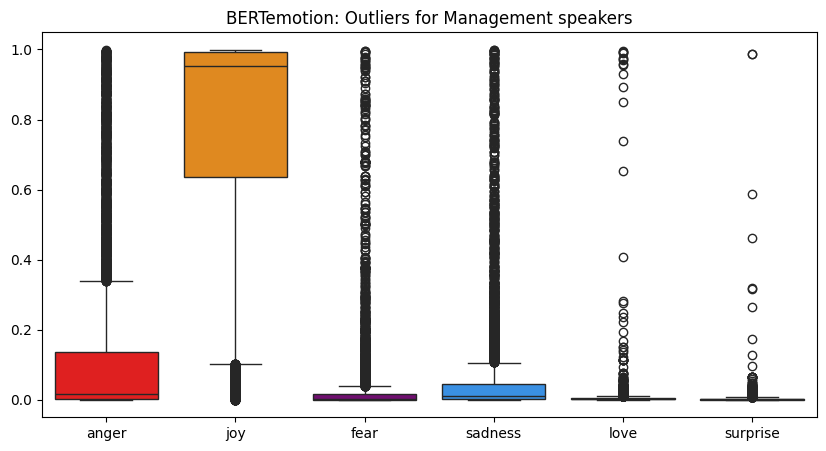

In [18]:
# Look for outliers in emotions of ubs_data where speaker_role = "management"
import seaborn as sns

# Visualize outliers of last 6 columns (emotions) using boxplots
# Display as vertical boxes on the same plot
management_data = data[data['speaker_role'] == 'management']
plt.figure(figsize=(10, 5))
sns.boxplot(data=management_data.iloc[:, -6:], palette=emotion_palette)
plt.title("BERTemotion: Outliers for Management speakers")
plt.show()

## Calculate quarterly emotion values (Management not Analyst)

In [19]:
# Create dataframe to calculate median and standard deviation of every emotion every quarter (UBS)
emotion_stats = data.groupby(["quarter", "main_emotion", "speaker_role","section"]).agg(
    median_score=("main_emotion_score", "median"),
    std_score=("main_emotion_score", "std")
    # if NaN values, replace with 0
).fillna(0).reset_index()

# Drop rows where speaker_role = analyst
emotion_stats = emotion_stats[emotion_stats['speaker_role'] != 'analyst']
emotion_stats.head(10)   

,quarter,main_emotion,speaker_role,section,median_score,std_score
1,2022-Q1,anger,management,prepared,0.799182,0.166682
2,2022-Q1,anger,management,qa,0.850514,0.190764
3,2022-Q1,anger,operator,qa,0.800260,0.181836
5,2022-Q1,fear,management,prepared,0.526307,0.225328
6,2022-Q1,fear,management,qa,0.679473,0.204472
8,2022-Q1,joy,management,prepared,0.952281,0.167174
9,2022-Q1,joy,management,qa,0.967848,0.138374
10,2022-Q1,joy,operator,qa,0.934335,0.000000
11,2022-Q1,love,management,qa,0.850105,0.000000
13,2022-Q1,sadness,management,prepared,0.536214,0.108511


In [20]:
# Calculate max and mean values for std_score
emotion_std_max = emotion_stats.groupby('main_emotion')['std_score'].max()
emotion_std_mean = emotion_stats.groupby('main_emotion')['std_score'].mean()
print("Max std_score per emotion:")
print(emotion_std_max)
print("\nMean std_score per emotion:")
print(emotion_std_mean)

Max std_score per emotion:
main_emotion
anger       0.245546
fear        0.259509
joy         0.168693
love        0.167770
sadness     0.336456
surprise    0.000000
Name: std_score, dtype: float64

Mean std_score per emotion:
main_emotion
anger       0.168972
fear        0.149319
joy         0.125034
love        0.025550
sadness     0.173614
surprise    0.000000
Name: std_score, dtype: float64


## Differences between Prepared and Q&A sections for all emotions

In [21]:
# Calculate differences between prepared and QA emotion scores for UBS management if NaN use zero
diff_emotion_stats = emotion_stats.pivot_table(index=['quarter', 'main_emotion'], columns='section', values='median_score').reset_index()
diff_emotion_stats = diff_emotion_stats.fillna(0)
diff_emotion_stats['diff'] = diff_emotion_stats['qa'] - diff_emotion_stats['prepared']

In [22]:
# Find max standard deviation from all emotions from emotion_std_max values
all_emotion_std_max = emotion_std_max.max()
print("Value for error bars: ", all_emotion_std_max)

Value for error bars:  0.3364563592747063


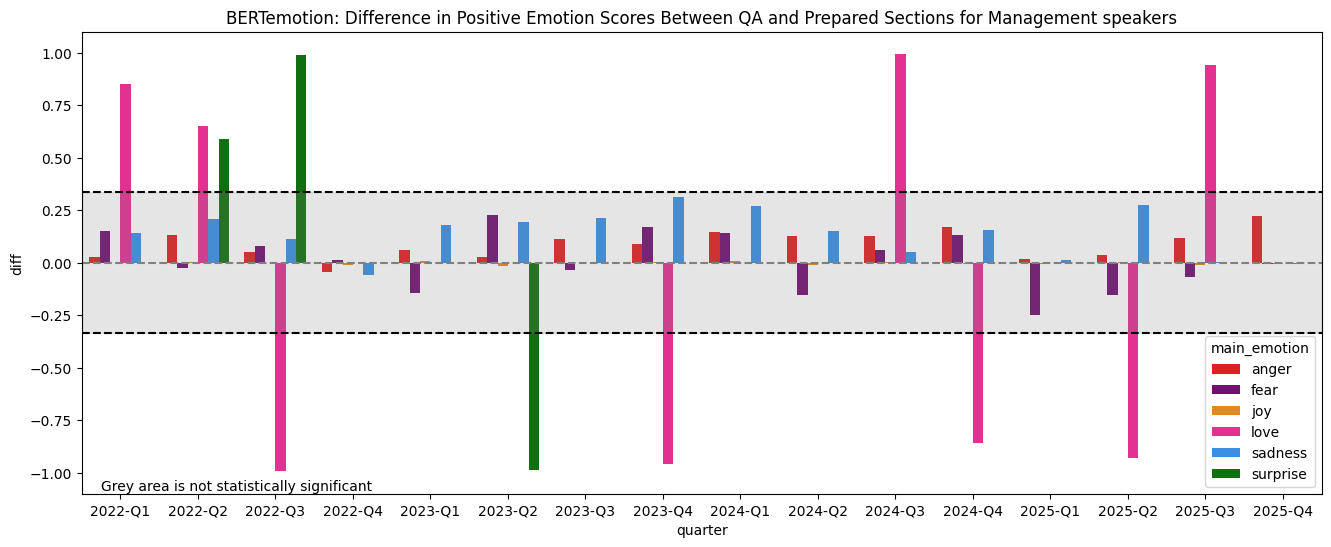

In [23]:
# Plot results as bar chart
plt.figure(figsize=(16, 6))
# fix y axis from 1.1 to -1.1
plt.ylim(-1.1, 1.1)
sns.barplot(data=diff_emotion_stats, x="quarter", y="diff", hue="main_emotion", palette=emotion_palette)
plt.title("Difference in Emotion Scores Between QA and Prepared Sections - Management (Excluding Analysts)")
plt.axhline(0, linestyle='--', color='gray')

# plot x-line at value of positive emotion standard deviation
plt.axhline(all_emotion_std_max, linestyle='--', color='black')
plt.axhline(-all_emotion_std_max, linestyle='--', color='black')
# infill area in grey across the whole x-axis
plt.axhspan(
    -all_emotion_std_max,
    all_emotion_std_max,
    color='grey',
    alpha=0.2
)

plt.title("BERTemotion: Difference in Positive Emotion Scores Between QA and Prepared Sections for Management speakers")

# Add text onto plot "Grey area represents ±1 standard deviation of positive emotion scores"
plt.text(
    x=1.5, 
    y=-1.1, 
    s="Grey area is not statistically significant", 
    color='black', 
    ha='center', 
    va='bottom'
)

# Save figure with bank name
plt.savefig(f"BERT_emotion_differences_{bank_name}.png")

### Merger period Q2 2022 to Q2 2024

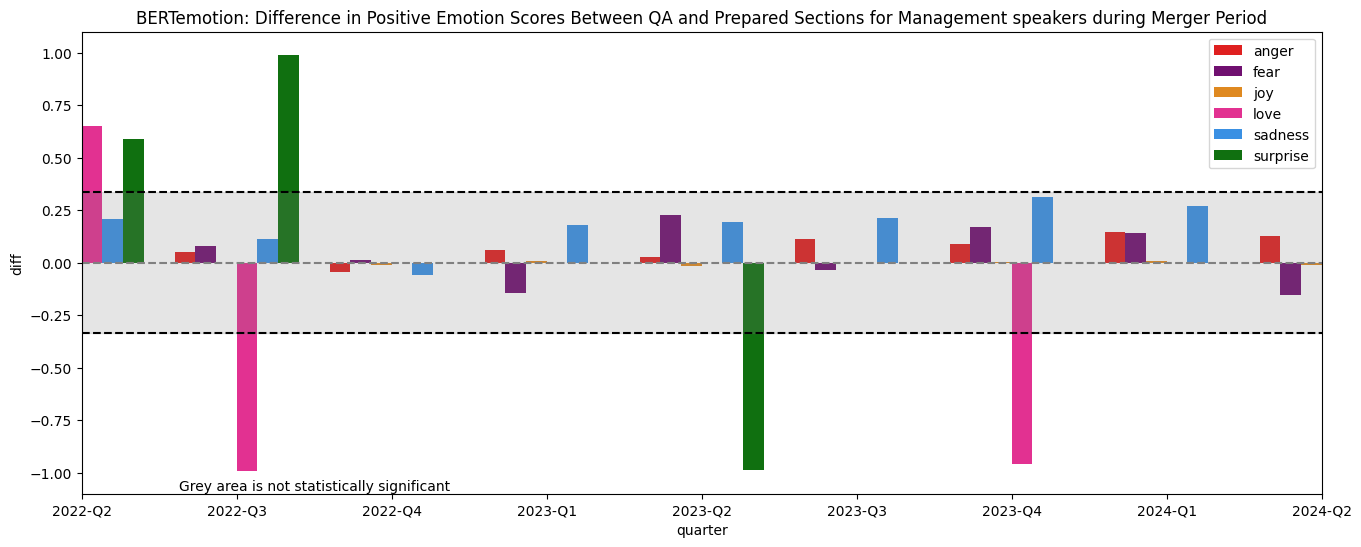

In [24]:
# Plot results as bar chart
plt.figure(figsize=(16, 6))
# fix y axis from 1.1 to -1.1
plt.ylim(-1.1, 1.1)
sns.barplot(data=diff_emotion_stats, x="quarter", y="diff", hue="main_emotion", palette=emotion_palette)
plt.title("Difference in Emotion Scores Between QA and Prepared Sections - Management (Excluding Analysts)")
plt.axhline(0, linestyle='--', color='gray')

#Set x-lim to include from 2022-Q2 to 2024-Q2
plt.xlim("2022-Q2", "2024-Q2")
# plot x-line at value of positive emotion standard deviation
plt.axhline(all_emotion_std_max, linestyle='--', color='black')
plt.axhline(-all_emotion_std_max, linestyle='--', color='black')
# infill area in grey across the whole x-axis
plt.axhspan(
    -all_emotion_std_max,
    all_emotion_std_max,
    color='grey',
    alpha=0.2
)

# move legend to upper right
plt.legend(loc='upper right')
plt.title("BERTemotion: Difference in Positive Emotion Scores Between QA and Prepared Sections for Management speakers during Merger Period")

# Add text onto plot "Grey area represents ±1 standard deviation of positive emotion scores"
plt.text(
    x=2.5, 
    y=-1.1, 
    s="Grey area is not statistically significant", 
    color='black', 
    ha='center', 
    va='bottom'
)

# Save figure with bank name
plt.savefig(f"BERT_emotion_differences_merge_period_{bank_name}.png")

# FinBERT Model

## Fix colours for sentiments

In [25]:
# Fix colours of bars to sentiment categories to be used in sns and matplotlib
sentiment_palette = {
    # For FinBERT model
    'positive': 'darkorange',
    'neutral': 'grey',
    'negative': 'dodgerblue',

    # For FinBERT-Tone model
    'Positive': 'darkorange',
    'Neutral': 'grey',
    'Negative': 'dodgerblue',

    # For FinBERT-Tone model (which also uses capitalized sentiment labels)
    'FBT_Positive': 'darkorange',
    'FBT_Neutral': 'grey',
    'FBT_Negative': 'dodgerblue',

    # For RoBERTa model
    'RBT_positive': 'darkorange',
    'RBT_neutral': 'grey',
    'RBT_negative': 'dodgerblue',
}

## Build pipeline

In [26]:
# Conduct sentiment analysis using FinBERT on UBS-related financial texts
from transformers import BertTokenizer, BertForSequenceClassification, pipeline

# Load FinBERT model and tokenizer
model_name = "prosusai/finbert"
tokenizer = BertTokenizer.from_pretrained(model_name)
model = BertForSequenceClassification.from_pretrained(model_name)

# Create sentiment analysis pipeline
sentiment_analyzer = pipeline("sentiment-analysis", model=model, tokenizer=tokenizer)

documents = (
    data["cleaned_text"]
    .apply(lambda tokens: " ".join(tokens) if isinstance(tokens, list) else str(tokens))
    .tolist()
 )

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 57187.30it/s]


## Run the model

In [27]:
# Run the model and keep all sentiment scores
basic_sentiment = sentiment_analyzer(documents, top_k=None, truncation=True)

# Flatten the model output into one dict per sentence
sentiment_rows = []
for result in basic_sentiment:
    if isinstance(result, list):
        sentiment_rows.append({entry["label"]: entry["score"] for entry in result})
    elif isinstance(result, dict):
        sentiment_rows.append({result["label"]: result["score"]})
    else:
        sentiment_rows.append({})

# Add the top sentiment and score to the dataframe
data["main_sentiment"] = [
    max(row, key=row.get, default="neutral") if row else "neutral"
    for row in sentiment_rows
]
data["main_sentiment_score"] = [
    row.get(max(row, key=row.get, default="neutral"), 0.0) if row else 0.0
    for row in sentiment_rows
]

# Add all sentiment columns as separate numeric columns
for sentiment in ["positive", "negative", "neutral"]:
    data[sentiment] = [row.get(sentiment, 0.0) for row in sentiment_rows]

In [28]:

data.head(10)

,bank,quarter,call_type,call_date,position_in_call,section,speaker_role,speaker_name,speaker_institution,sentence_id,...,joy,fear,sadness,love,surprise,main_sentiment,main_sentiment_score,positive,negative,neutral
9905,UBS,2022-Q1,earnings,2022-04-26,1,prepared,management,Ralph Hamers,NaN,33595,...,0.970431,0.000758,0.003116,0.022439,0.001162,neutral,0.876172,0.087840,0.035989,0.876172
9907,UBS,2022-Q1,earnings,2022-04-26,1,prepared,management,Ralph Hamers,NaN,33597,...,0.061112,0.030817,0.009822,0.003346,0.005143,negative,0.720507,0.021334,0.720507,0.258159
9908,UBS,2022-Q1,earnings,2022-04-26,1,prepared,management,Ralph Hamers,NaN,33598,...,0.528087,0.021344,0.197962,0.006077,0.001771,neutral,0.920784,0.061932,0.017284,0.920784
9909,UBS,2022-Q1,earnings,2022-04-26,1,prepared,management,Ralph Hamers,NaN,33599,...,0.995580,0.000572,0.001534,0.000571,0.000814,positive,0.841943,0.841943,0.008035,0.150022
9910,UBS,2022-Q1,earnings,2022-04-26,1,prepared,management,Ralph Hamers,NaN,33600,...,0.990656,0.000684,0.003835,0.000565,0.000345,neutral,0.836954,0.108468,0.054578,0.836954
9911,UBS,2022-Q1,earnings,2022-04-26,1,prepared,management,Ralph Hamers,NaN,33601,...,0.528034,0.050579,0.024011,0.009967,0.002212,neutral,0.875320,0.105465,0.019216,0.875320
9912,UBS,2022-Q1,earnings,2022-04-26,1,prepared,management,Ralph Hamers,NaN,33602,...,0.961699,0.009443,0.012983,0.003805,0.001493,neutral,0.877357,0.106893,0.015750,0.877357
9913,UBS,2022-Q1,earnings,2022-04-26,1,prepared,management,Ralph Hamers,NaN,33603,...,0.032300,0.074753,0.513293,0.002004,0.001990,positive,0.539305,0.539305,0.011700,0.448995
9914,UBS,2022-Q1,earnings,2022-04-26,1,prepared,management,Ralph Hamers,NaN,33604,...,0.994181,0.000640,0.002659,0.000802,0.000247,positive,0.953584,0.953584,0.022028,0.024387
9915,UBS,2022-Q1,earnings,2022-04-26,1,prepared,management,Ralph Hamers,NaN,33605,...,0.994900,0.000455,0.001594,0.001426,0.000398,neutral,0.763131,0.225490,0.011379,0.763131


## Check outliers
Use boxplots to check shape of data for outliers. Suspect data is noisy hence using the median values rather than the mean if the data is skewed.

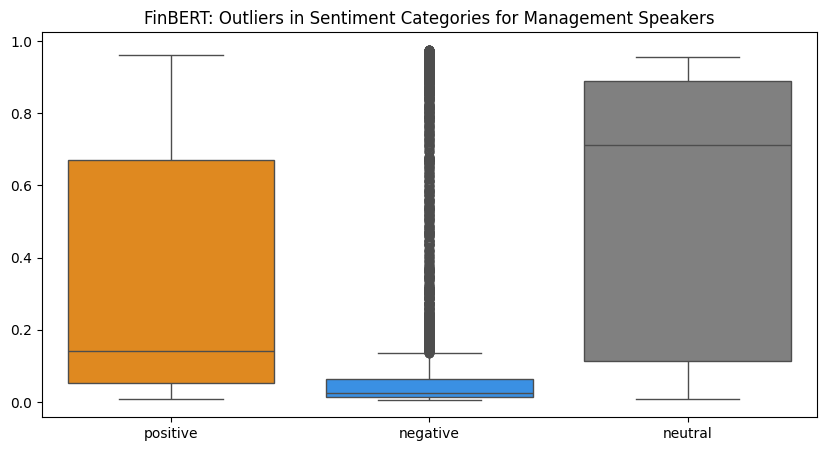

In [29]:
# Look for outliers in sentiments categories of data where speaker_role = "management"
# Display as vertical boxes on the same plot
management_data = data[data['speaker_role'] == 'management']
plt.figure(figsize=(10, 5))
sns.boxplot(data=management_data.iloc[:, -3:], palette=sentiment_palette)
plt.title("FinBERT: Outliers in Sentiment Categories for Management Speakers")
plt.show()

## Calculate quarterly sentiment values (Management not Analyst)

In [30]:
# Create dataframe to calculate median and standard deviation of every sentiment every quarter (UBS)
sentiment_stats = data.groupby(["quarter", "main_sentiment", "speaker_role","section"]).agg(
    median_score=("main_sentiment_score", "median"),
    std_score=("main_sentiment_score", "std")
    # if NaN values, replace with 0
).fillna(0).reset_index()

# Drop rows where speaker_role = analyst
sentiment_stats = sentiment_stats[sentiment_stats['speaker_role'] != 'analyst']
sentiment_stats.head(10)   

,quarter,main_sentiment,speaker_role,section,median_score,std_score
1,2022-Q1,negative,management,prepared,0.901146,0.152136
2,2022-Q1,negative,management,qa,0.804496,0.156226
4,2022-Q1,neutral,management,prepared,0.855210,0.121000
5,2022-Q1,neutral,management,qa,0.873643,0.105181
6,2022-Q1,neutral,operator,qa,0.937911,0.007956
8,2022-Q1,positive,management,prepared,0.854419,0.142954
9,2022-Q1,positive,management,qa,0.858118,0.164029
11,2022-Q2,negative,management,prepared,0.840278,0.179188
12,2022-Q2,negative,management,qa,0.689240,0.162857
14,2022-Q2,neutral,management,prepared,0.870767,0.134849


In [31]:
# Calculate max and mean values for std_score for sentiments
sentiment_std_max = sentiment_stats.groupby('main_sentiment')['std_score'].max()
sentiment_std_mean = sentiment_stats.groupby('main_sentiment')['std_score'].mean()
print("Max std_score per sentiment:")
print(sentiment_std_max)
print("\nMean std_score per sentiment:")
print(sentiment_std_mean)

Max std_score per sentiment:
main_sentiment
negative    0.210365
neutral     0.153982
positive    0.165190
Name: std_score, dtype: float64

Mean std_score per sentiment:
main_sentiment
negative    0.148183
neutral     0.107328
positive    0.136539
Name: std_score, dtype: float64


## Differences between Prepared and Q&A sections

In [32]:
# Calculate differences between prepared and QA sentiment scores for management if NaN use zero
diff_sentiment_stats = sentiment_stats.pivot_table(index=['quarter', 'main_sentiment'], columns='section', values='median_score').reset_index()
diff_sentiment_stats = diff_sentiment_stats.fillna(0)
diff_sentiment_stats['diff'] = diff_sentiment_stats['qa'] - diff_sentiment_stats['prepared']

In [33]:
diff_sentiment_stats.head(10)

section,quarter,main_sentiment,prepared,qa,diff
0,2022-Q1,negative,0.901146,0.804496,-0.096650
1,2022-Q1,neutral,0.855210,0.905777,0.050567
2,2022-Q1,positive,0.854419,0.858118,0.003699
3,2022-Q2,negative,0.840278,0.689240,-0.151038
4,2022-Q2,neutral,0.870767,0.889660,0.018893
5,2022-Q2,positive,0.912851,0.856140,-0.056711
6,2022-Q3,negative,0.882035,0.671236,-0.210800
7,2022-Q3,neutral,0.800737,0.883087,0.082351
8,2022-Q3,positive,0.903610,0.825514,-0.078096
9,2022-Q4,negative,0.855661,0.799376,-0.056285


In [34]:
# Find max standard deviation from all emotions from sentiment_std_max values
all_sentiment_std_max = sentiment_std_max.max()
print("Value for error bars: ", all_sentiment_std_max)

Value for error bars:  0.21036466157180372


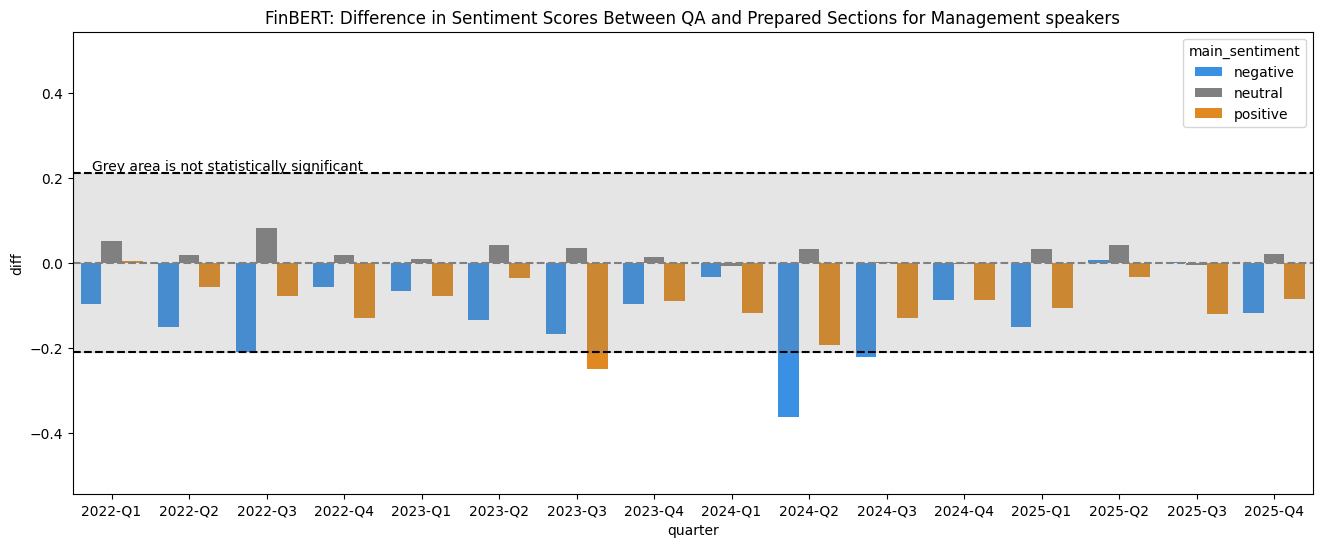

In [35]:
# Plot results as bar chart
plt.figure(figsize=(16, 6))
# fix y axis from 1.1 to -1.1
#plt.ylim(-1.1, 1.1)
sns.barplot(data=diff_sentiment_stats, x="quarter", y="diff", hue="main_sentiment", palette=sentiment_palette)

# Median scores are close to 1 in both sections, so the diff is tiny; zoom in to see it
diff_range = diff_sentiment_stats['diff'].abs().max() * 1.5
plt.ylim(-diff_range, diff_range)

plt.title("Difference in Sentiment Scores Between QA and Prepared Sections - Management (Excluding Analysts)")
plt.axhline(0, linestyle='--', color='gray')

# plot x-line at value of positive emotion standard deviation
plt.axhline(all_sentiment_std_max, linestyle='--', color='black')
plt.axhline(-all_sentiment_std_max, linestyle='--', color='black')
# infill area in grey across the whole x-axis
plt.axhspan(
    -all_sentiment_std_max,
    all_sentiment_std_max,
    color='grey',
    alpha=0.2
)

plt.title("FinBERT: Difference in Sentiment Scores Between QA and Prepared Sections for Management speakers")

# Add text onto plot "Grey area represents ±1 standard deviation of positive emotion scores"
plt.text(
    x=1.5, 
    y=all_sentiment_std_max, 
    s="Grey area is not statistically significant", 
    color='black', 
    ha='center', 
    va='bottom'
)

# Save figure with bank name
plt.savefig(f"FinBERT_sentiment_differences_{bank_name}.png")

### Merger period Q2 2022 to Q2 2024

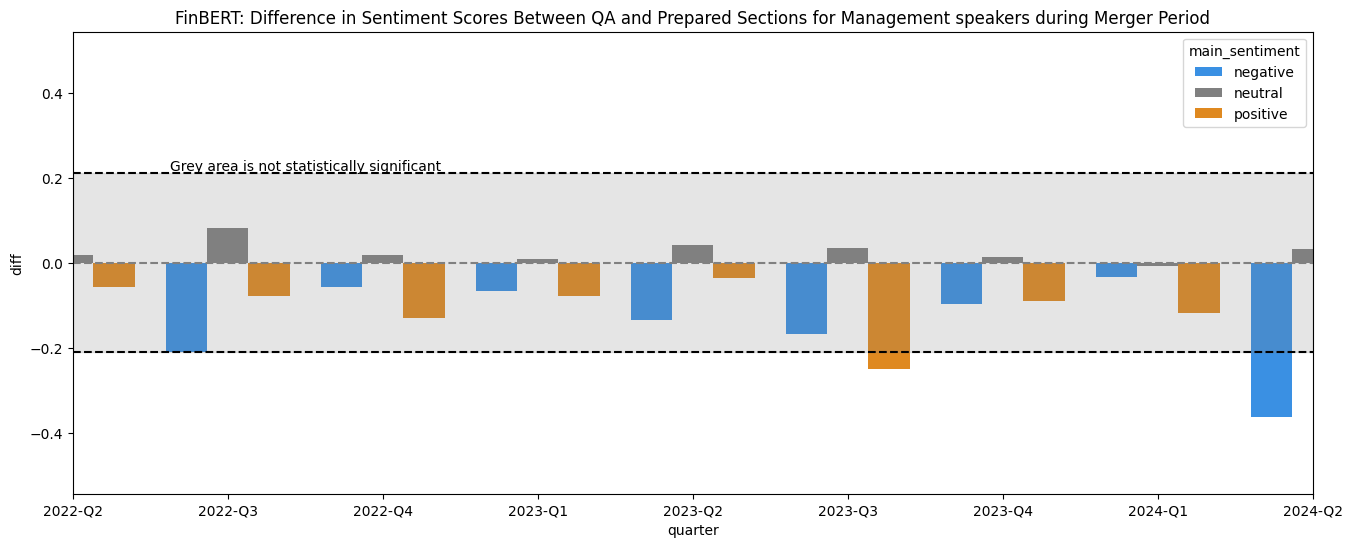

In [36]:
# Plot results as bar chart
plt.figure(figsize=(16, 6))
# fix y axis from 1.1 to -1.1
#plt.ylim(-1.1, 1.1)
sns.barplot(data=diff_sentiment_stats, x="quarter", y="diff", hue="main_sentiment", palette=sentiment_palette)

# Median scores are close to 1 in both sections, so the diff is tiny; zoom in to see it
diff_range = diff_sentiment_stats['diff'].abs().max() * 1.5
plt.ylim(-diff_range, diff_range)

# set x-lim to include from 2022-Q2 to 2024-Q2
plt.xlim("2022-Q2", "2024-Q2")
plt.title("Difference in Sentiment Scores Between QA and Prepared Sections - Management (Excluding Analysts)")
plt.axhline(0, linestyle='--', color='gray')

# plot x-line at value of positive emotion standard deviation
plt.axhline(all_sentiment_std_max, linestyle='--', color='black')
plt.axhline(-all_sentiment_std_max, linestyle='--', color='black')
# infill area in grey across the whole x-axis
plt.axhspan(
    -all_sentiment_std_max,
    all_sentiment_std_max,
    color='grey',
    alpha=0.2
)

plt.title("FinBERT: Difference in Sentiment Scores Between QA and Prepared Sections for Management speakers during Merger Period")

# Add text onto plot "Grey area represents ±1 standard deviation of positive emotion scores"
plt.text(
    x=2.5, 
    y=all_sentiment_std_max, 
    s="Grey area is not statistically significant", 
    color='black', 
    ha='center', 
    va='bottom'
)

# Save figure with bank name
plt.savefig(f"FinBERT_sentiment_differences_merge_period_{bank_name}.png")

# Compare FinBERT and BERTemotion

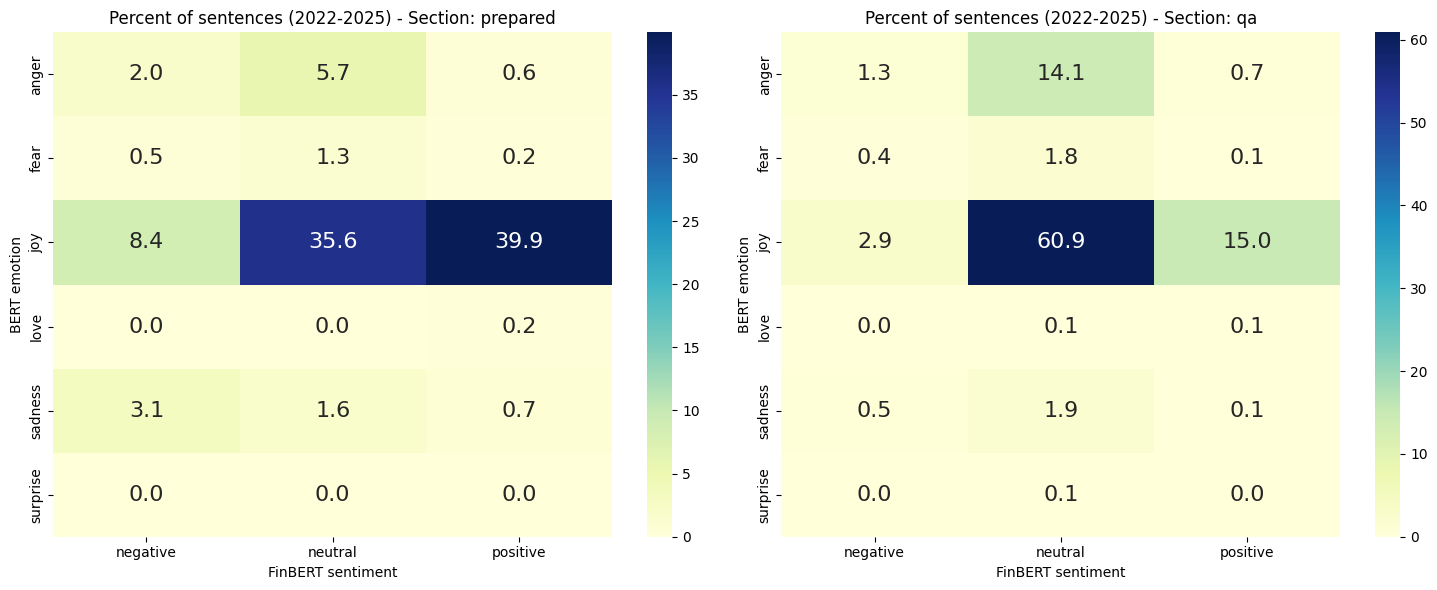

In [37]:
# Create two heatmaps side by side with speaker_role = management but split by section

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Display values as % of total number in large font
sections = data['section'].unique()
for i, section in enumerate(sections[:2]):  # Only take the first two sections for side by side comparison
    heatmap_data = pd.crosstab(
        data.loc[(data['speaker_role'] == 'management') & (data['section'] == section), 'main_emotion'],
        data.loc[(data['speaker_role'] == 'management') & (data['section'] == section), 'main_sentiment']
    )
    heatmap_data = heatmap_data / heatmap_data.values.sum() * 100  # Convert to percentage
    sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap="YlGnBu", ax=axes[i], annot_kws={"size": 16})
    axes[i].set_xlabel('FinBERT sentiment')
    axes[i].set_ylabel('BERT emotion')
    axes[i].set_title(f'Percent of sentences (2022-2025) - Section: {section}')

plt.tight_layout()

# Save each subplot as its own image using its extent, plus the combined figure
for i, section in enumerate(sections[:2]):
    extent = axes[i].get_tightbbox(fig.canvas.get_renderer()).transformed(fig.dpi_scale_trans.inverted())

fig.savefig(f'BERT_emotion_vs_FinBERT_{bank_name}.png')
plt.show()

# FinBERT-Tone Model

## Build pipeline

In [38]:
# Conduct sentiment analysis using FinBERT on UBS-related financial texts
from transformers import BertTokenizer, BertForSequenceClassification, pipeline

# Load FinBERT model and tokenizer
model_name = "yiyanghkust/finbert-tone"
tokenizer = BertTokenizer.from_pretrained(model_name)
model = BertForSequenceClassification.from_pretrained(model_name)

# Create sentiment analysis pipeline
sentiment_analyzer = pipeline("sentiment-analysis", model=model, tokenizer=tokenizer)

documents = (
    data["cleaned_text"]
    .apply(lambda tokens: " ".join(tokens) if isinstance(tokens, list) else str(tokens))
    .tolist()
 )

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 69992.12it/s]


## Run the model

In [39]:
# Run the model and keep all sentiment scores
basic_FBT_sentiment = sentiment_analyzer(documents, top_k=None, truncation=True)

# Flatten the model output into one dict per sentence
sentiment_rows = []
for result in basic_FBT_sentiment:
    if isinstance(result, list):
        sentiment_rows.append({entry["label"]: entry["score"] for entry in result})
    elif isinstance(result, dict):
        sentiment_rows.append({result["label"]: result["score"]})
    else:
        sentiment_rows.append({})

# Add the top sentiment and score to the dataframe
data["FBT_Main_Sentiment"] = [
    max(row, key=row.get, default="Neutral") if row else "Neutral"
    for row in sentiment_rows
]
data["FBT_Main_Sentiment_Score"] = [
    row.get(max(row, key=row.get, default="Neutral"), 0.0) if row else 0.0
    for row in sentiment_rows
]

# Add all sentiment columns as separate numeric columns
# NOTE: FinBERT-Tone requires capital letters for the sentiment labels
for sentiment in ["Positive", "Negative", "Neutral"]:
    data[sentiment] = [row.get(sentiment, 0.0) for row in sentiment_rows]

In [40]:
data.head(10)

,bank,quarter,call_type,call_date,position_in_call,section,speaker_role,speaker_name,speaker_institution,sentence_id,...,main_sentiment,main_sentiment_score,positive,negative,neutral,FBT_Main_Sentiment,FBT_Main_Sentiment_Score,Positive,Negative,Neutral
9905,UBS,2022-Q1,earnings,2022-04-26,1,prepared,management,Ralph Hamers,NaN,33595,...,neutral,0.876172,0.087840,0.035989,0.876172,Neutral,0.633788,0.363612,2.599858e-03,6.337882e-01
9907,UBS,2022-Q1,earnings,2022-04-26,1,prepared,management,Ralph Hamers,NaN,33597,...,negative,0.720507,0.021334,0.720507,0.258159,Neutral,0.762569,0.000298,2.371330e-01,7.625688e-01
9908,UBS,2022-Q1,earnings,2022-04-26,1,prepared,management,Ralph Hamers,NaN,33598,...,neutral,0.920784,0.061932,0.017284,0.920784,Neutral,0.995665,0.001492,2.842489e-03,9.956655e-01
9909,UBS,2022-Q1,earnings,2022-04-26,1,prepared,management,Ralph Hamers,NaN,33599,...,positive,0.841943,0.841943,0.008035,0.150022,Positive,1.000000,1.000000,1.214168e-07,7.975387e-08
9910,UBS,2022-Q1,earnings,2022-04-26,1,prepared,management,Ralph Hamers,NaN,33600,...,neutral,0.836954,0.108468,0.054578,0.836954,Positive,0.999991,0.999991,3.106961e-06,6.054839e-06
9911,UBS,2022-Q1,earnings,2022-04-26,1,prepared,management,Ralph Hamers,NaN,33601,...,neutral,0.875320,0.105465,0.019216,0.875320,Neutral,0.770857,0.216085,1.305848e-02,7.708570e-01
9912,UBS,2022-Q1,earnings,2022-04-26,1,prepared,management,Ralph Hamers,NaN,33602,...,neutral,0.877357,0.106893,0.015750,0.877357,Positive,0.493373,0.493373,3.690699e-02,4.697201e-01
9913,UBS,2022-Q1,earnings,2022-04-26,1,prepared,management,Ralph Hamers,NaN,33603,...,positive,0.539305,0.539305,0.011700,0.448995,Positive,0.892135,0.892135,9.678640e-02,1.107843e-02
9914,UBS,2022-Q1,earnings,2022-04-26,1,prepared,management,Ralph Hamers,NaN,33604,...,positive,0.953584,0.953584,0.022028,0.024387,Positive,1.000000,1.000000,9.094462e-09,1.852140e-09
9915,UBS,2022-Q1,earnings,2022-04-26,1,prepared,management,Ralph Hamers,NaN,33605,...,neutral,0.763131,0.225490,0.011379,0.763131,Positive,0.962873,0.962873,2.285548e-04,3.689864e-02


In [41]:
# Update FinBERT-Tone column names to make it clearer
data.rename(
    columns={
        "Positive": "FBT_Positive",
        "Negative": "FBT_Negative",
        "Neutral": "FBT_Neutral",
    },
    inplace=True,
)
data.head(10)

,bank,quarter,call_type,call_date,position_in_call,section,speaker_role,speaker_name,speaker_institution,sentence_id,...,main_sentiment,main_sentiment_score,positive,negative,neutral,FBT_Main_Sentiment,FBT_Main_Sentiment_Score,FBT_Positive,FBT_Negative,FBT_Neutral
9905,UBS,2022-Q1,earnings,2022-04-26,1,prepared,management,Ralph Hamers,NaN,33595,...,neutral,0.876172,0.087840,0.035989,0.876172,Neutral,0.633788,0.363612,2.599858e-03,6.337882e-01
9907,UBS,2022-Q1,earnings,2022-04-26,1,prepared,management,Ralph Hamers,NaN,33597,...,negative,0.720507,0.021334,0.720507,0.258159,Neutral,0.762569,0.000298,2.371330e-01,7.625688e-01
9908,UBS,2022-Q1,earnings,2022-04-26,1,prepared,management,Ralph Hamers,NaN,33598,...,neutral,0.920784,0.061932,0.017284,0.920784,Neutral,0.995665,0.001492,2.842489e-03,9.956655e-01
9909,UBS,2022-Q1,earnings,2022-04-26,1,prepared,management,Ralph Hamers,NaN,33599,...,positive,0.841943,0.841943,0.008035,0.150022,Positive,1.000000,1.000000,1.214168e-07,7.975387e-08
9910,UBS,2022-Q1,earnings,2022-04-26,1,prepared,management,Ralph Hamers,NaN,33600,...,neutral,0.836954,0.108468,0.054578,0.836954,Positive,0.999991,0.999991,3.106961e-06,6.054839e-06
9911,UBS,2022-Q1,earnings,2022-04-26,1,prepared,management,Ralph Hamers,NaN,33601,...,neutral,0.875320,0.105465,0.019216,0.875320,Neutral,0.770857,0.216085,1.305848e-02,7.708570e-01
9912,UBS,2022-Q1,earnings,2022-04-26,1,prepared,management,Ralph Hamers,NaN,33602,...,neutral,0.877357,0.106893,0.015750,0.877357,Positive,0.493373,0.493373,3.690699e-02,4.697201e-01
9913,UBS,2022-Q1,earnings,2022-04-26,1,prepared,management,Ralph Hamers,NaN,33603,...,positive,0.539305,0.539305,0.011700,0.448995,Positive,0.892135,0.892135,9.678640e-02,1.107843e-02
9914,UBS,2022-Q1,earnings,2022-04-26,1,prepared,management,Ralph Hamers,NaN,33604,...,positive,0.953584,0.953584,0.022028,0.024387,Positive,1.000000,1.000000,9.094462e-09,1.852140e-09
9915,UBS,2022-Q1,earnings,2022-04-26,1,prepared,management,Ralph Hamers,NaN,33605,...,neutral,0.763131,0.225490,0.011379,0.763131,Positive,0.962873,0.962873,2.285548e-04,3.689864e-02


## Check outliers
Use boxplots to check shape of data for outliers. Suspect data is noisy hence using the median values rather than the mean if the data is skewed.

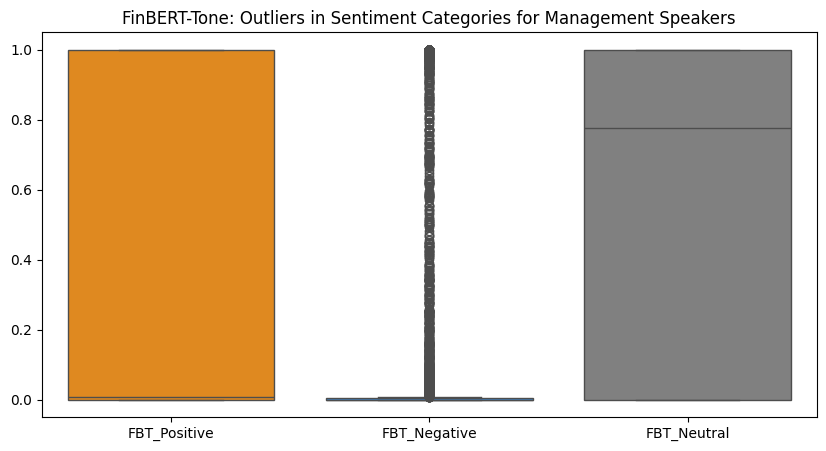

In [42]:
# Look for outliers in sentiments categories of data where speaker_role = "management"
# Display as vertical boxes on the same plot
management_data = data[data['speaker_role'] == 'management']
plt.figure(figsize=(10, 5))
# Use FBT_ columns for the boxplot
sns.boxplot(data=management_data[['FBT_Positive', 'FBT_Negative', 'FBT_Neutral']], palette=sentiment_palette)
plt.title("FinBERT-Tone: Outliers in Sentiment Categories for Management Speakers")
plt.show()

## Calculate quarterly sentiment values (Management not Analyst)

In [43]:
# Create dataframe to calculate median and standard deviation of every sentiment every quarter (UBS)
FBT_sentiment_stats = data.groupby(["quarter", "FBT_Main_Sentiment", "speaker_role","section"]).agg(
    median_score=("FBT_Main_Sentiment_Score", "median"),
    std_score=("FBT_Main_Sentiment_Score", "std")
    # if NaN values, replace with 0
).fillna(0).reset_index()

# Drop rows where speaker_role = analyst
FBT_sentiment_stats = FBT_sentiment_stats[FBT_sentiment_stats['speaker_role'] != 'analyst']
FBT_sentiment_stats.head(10)   

,quarter,FBT_Main_Sentiment,speaker_role,section,median_score,std_score
1,2022-Q1,Negative,management,prepared,0.999786,0.122974
2,2022-Q1,Negative,management,qa,0.999315,0.198772
4,2022-Q1,Neutral,management,prepared,0.997938,0.108780
5,2022-Q1,Neutral,management,qa,0.997612,0.104792
6,2022-Q1,Neutral,operator,qa,0.994041,0.006095
8,2022-Q1,Positive,management,prepared,0.999992,0.105658
9,2022-Q1,Positive,management,qa,0.999486,0.113288
11,2022-Q2,Negative,management,prepared,0.999560,0.094979
12,2022-Q2,Negative,management,qa,0.950372,0.192876
14,2022-Q2,Neutral,management,prepared,0.999196,0.094433


In [44]:
# Calculate max and mean values for std_score for sentiments
FBT_sentiment_std_max = FBT_sentiment_stats.groupby('FBT_Main_Sentiment')['std_score'].max()
FBT_sentiment_std_mean = FBT_sentiment_stats.groupby('FBT_Main_Sentiment')['std_score'].mean()
print("Max std_score per sentiment:")
print(FBT_sentiment_std_max)
print("\nMean std_score per sentiment:")
print(FBT_sentiment_std_mean)

Max std_score per sentiment:
FBT_Main_Sentiment
Negative    0.203651
Neutral     0.122967
Positive    0.152331
Name: std_score, dtype: float64

Mean std_score per sentiment:
FBT_Main_Sentiment
Negative    0.146120
Neutral     0.091212
Positive    0.099219
Name: std_score, dtype: float64


## Differences between Prepared and Q&A sections

In [45]:
# Calculate differences between prepared and QA sentiment scores for management if NaN use zero
diff_FBT_sentiment_stats = FBT_sentiment_stats.pivot_table(index=['quarter', 'FBT_Main_Sentiment'], columns='section', values='median_score').reset_index()
diff_FBT_sentiment_stats = diff_FBT_sentiment_stats.fillna(0)
diff_FBT_sentiment_stats['diff'] = diff_FBT_sentiment_stats['qa'] - diff_FBT_sentiment_stats['prepared']

In [46]:
diff_FBT_sentiment_stats.head(10)

section,quarter,FBT_Main_Sentiment,prepared,qa,diff
0,2022-Q1,Negative,0.999786,0.999315,-0.000472
1,2022-Q1,Neutral,0.997938,0.995827,-0.002111
2,2022-Q1,Positive,0.999992,0.999486,-0.000505
3,2022-Q2,Negative,0.999560,0.950372,-0.049188
4,2022-Q2,Neutral,0.999196,0.998831,-0.000365
5,2022-Q2,Positive,0.999998,0.999960,-0.000038
6,2022-Q3,Negative,0.998613,0.987411,-0.011201
7,2022-Q3,Neutral,0.999261,0.998922,-0.000339
8,2022-Q3,Positive,0.999993,0.999722,-0.000271
9,2022-Q4,Negative,0.999108,0.683877,-0.315231


In [47]:
# Find max standard deviation from all emotions from sentiment_std_max values
all_FBT_sentiment_std_max = FBT_sentiment_std_max.max()
print("Value for error bars: ", all_FBT_sentiment_std_max)

Value for error bars:  0.2036514691118121


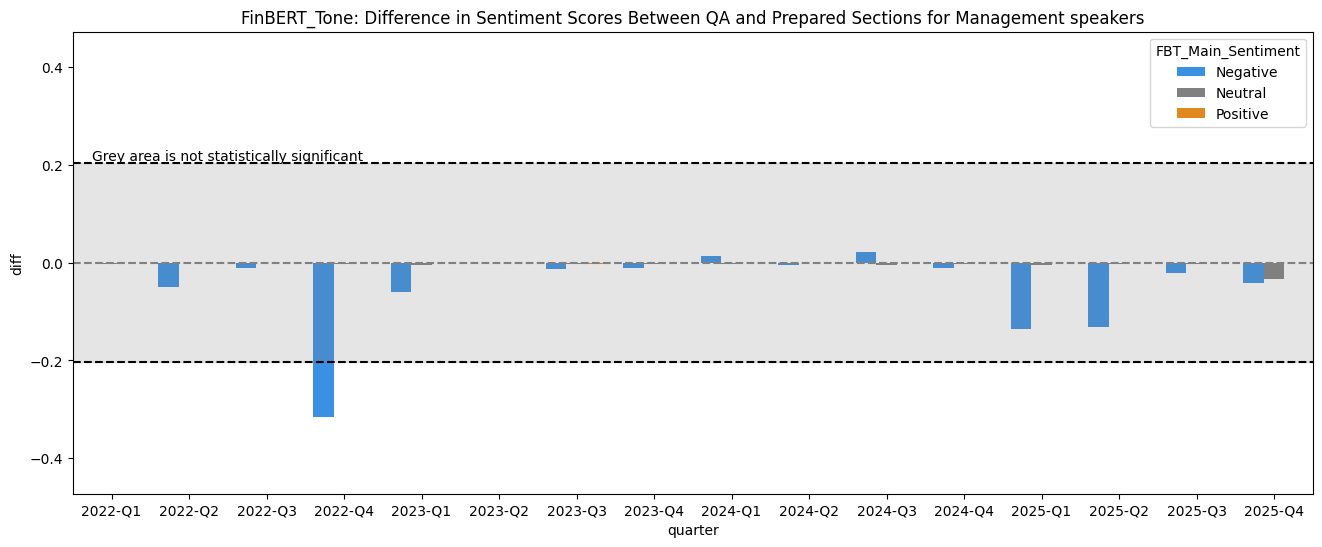

In [48]:
# Plot results as bar chart
plt.figure(figsize=(16, 6))
# fix y axis from 1.1 to -1.1
#plt.ylim(-1.1, 1.1)
sns.barplot(data=diff_FBT_sentiment_stats, x="quarter", y="diff", hue="FBT_Main_Sentiment", palette=sentiment_palette)

# Median scores are close to 1 in both sections, so the diff is tiny; zoom in to see it
FBT_diff_range = diff_FBT_sentiment_stats['diff'].abs().max() * 1.5
plt.ylim(-FBT_diff_range, FBT_diff_range)

plt.title("Difference in Sentiment Scores Between QA and Prepared Sections - Management (Excluding Analysts)")
plt.axhline(0, linestyle='--', color='gray')

# plot x-line at value of positive emotion standard deviation
plt.axhline(all_FBT_sentiment_std_max, linestyle='--', color='black')
plt.axhline(-all_FBT_sentiment_std_max, linestyle='--', color='black')
# infill area in grey across the whole x-axis
plt.axhspan(
    -all_FBT_sentiment_std_max,
    all_FBT_sentiment_std_max,
    color='grey',
    alpha=0.2
)

plt.title("FinBERT_Tone: Difference in Sentiment Scores Between QA and Prepared Sections for Management speakers")

# Add text onto plot "Grey area represents ±1 standard deviation of positive emotion scores"
plt.text(
    x=1.5, 
    y=all_FBT_sentiment_std_max, 
    s="Grey area is not statistically significant", 
    color='black', 
    ha='center', 
    va='bottom'
)

# Save figure with bank name
plt.savefig(f"FinBERT-Tone_sentiment_differences_{bank_name}.png")

# Compare FinBERT-Tone and BERT-Emotion

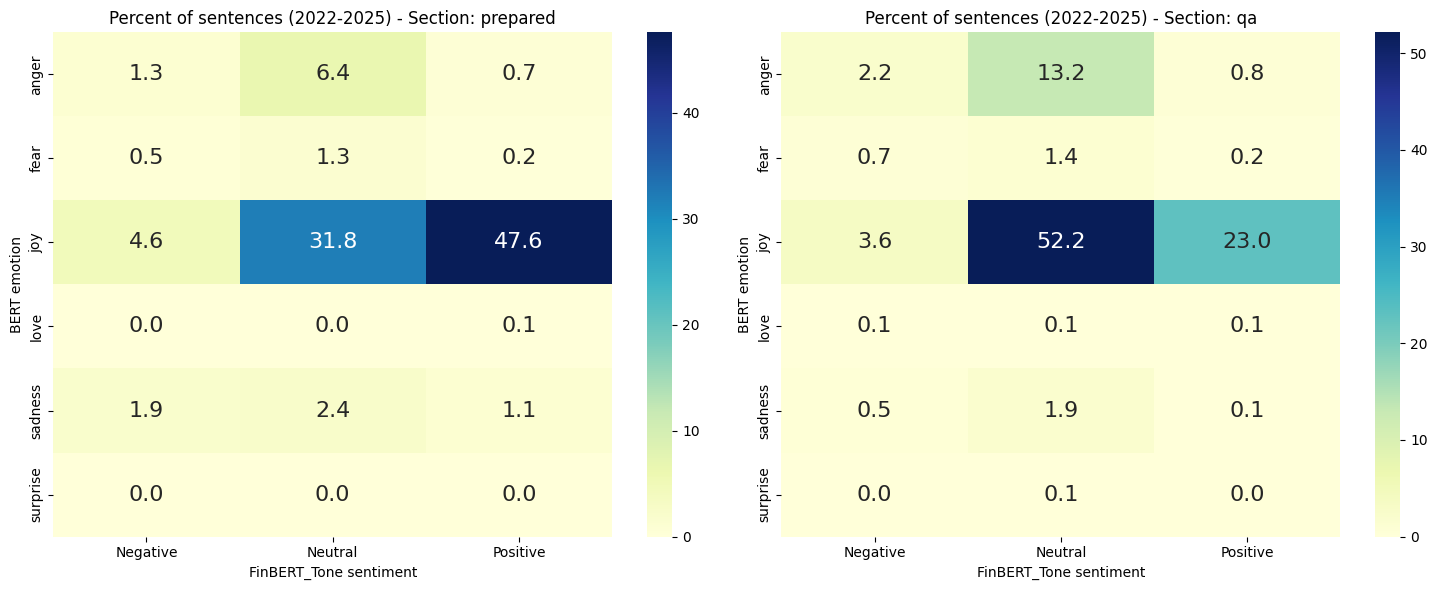

In [49]:
# Create two heatmaps side by side with speaker_role = management but split by section

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Display values as % of total number in large font
sections = data['section'].unique()
for i, section in enumerate(sections[:2]):  # Only take the first two sections for side by side comparison
    heatmap_data = pd.crosstab(
        data.loc[(data['speaker_role'] == 'management') & (data['section'] == section), 'main_emotion'],
        data.loc[(data['speaker_role'] == 'management') & (data['section'] == section), 'FBT_Main_Sentiment']
    )
    heatmap_data = heatmap_data / heatmap_data.values.sum() * 100  # Convert to percentage
    sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap="YlGnBu", ax=axes[i], annot_kws={"size": 16})
    axes[i].set_xlabel('FinBERT_Tone sentiment')
    axes[i].set_ylabel('BERT emotion')
    axes[i].set_title(f'Percent of sentences (2022-2025) - Section: {section}')

plt.tight_layout()

# Save each subplot as its own image using its extent, plus the combined figure
for i, section in enumerate(sections[:2]):
    extent = axes[i].get_tightbbox(fig.canvas.get_renderer()).transformed(fig.dpi_scale_trans.inverted())

fig.savefig(f'BERT_emotion_vs_FinBERT_Tone_{bank_name}.png')
plt.show()

# Compare FinBERT-Tone and FinBERT

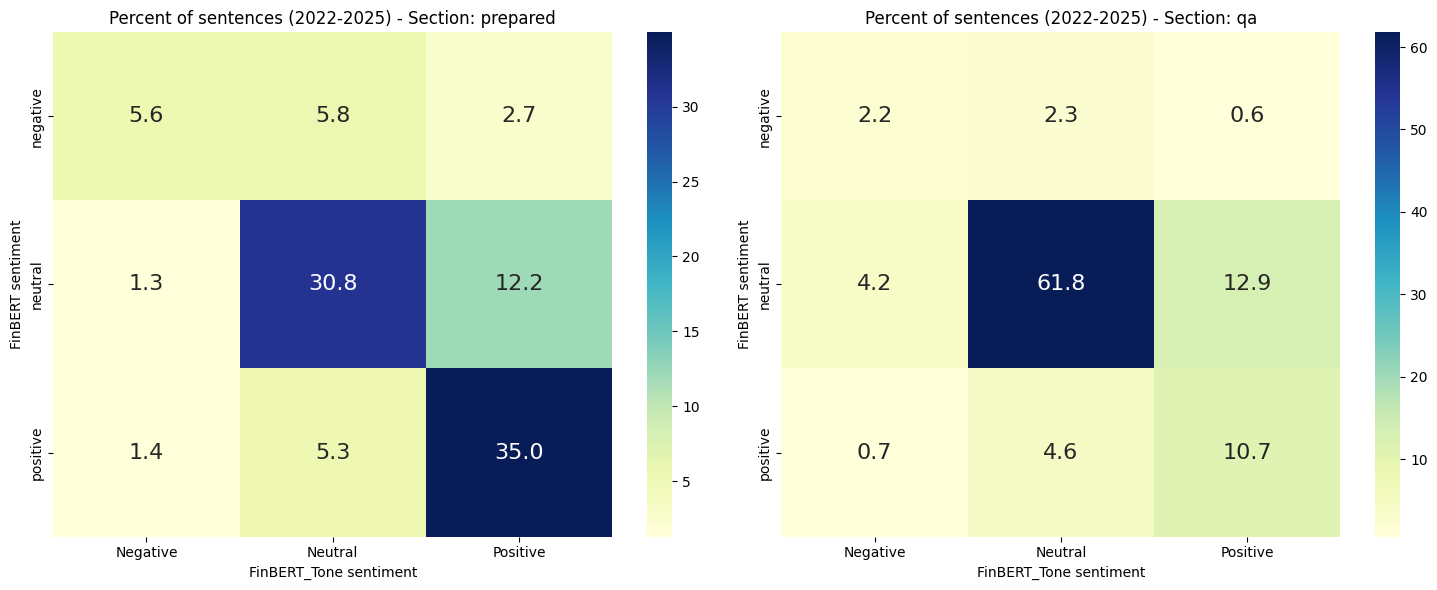

In [50]:
# Create two heatmaps side by side with speaker_role = management but split by section

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Display values as % of total number in large font
sections = data['section'].unique()
for i, section in enumerate(sections[:2]):  # Only take the first two sections for side by side comparison
    heatmap_data = pd.crosstab(
        data.loc[(data['speaker_role'] == 'management') & (data['section'] == section), 'main_sentiment'],
        data.loc[(data['speaker_role'] == 'management') & (data['section'] == section), 'FBT_Main_Sentiment']
    )
    heatmap_data = heatmap_data / heatmap_data.values.sum() * 100  # Convert to percentage
    sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap="YlGnBu", ax=axes[i], annot_kws={"size": 16})
    axes[i].set_xlabel('FinBERT_Tone sentiment')
    axes[i].set_ylabel('FinBERT sentiment')
    axes[i].set_title(f'Percent of sentences (2022-2025) - Section: {section}')

plt.tight_layout()

# Save each subplot as its own image using its extent, plus the combined figure
for i, section in enumerate(sections[:2]):
    extent = axes[i].get_tightbbox(fig.canvas.get_renderer()).transformed(fig.dpi_scale_trans.inverted())

fig.savefig(f'FinBERT_vs_FinBERT_Tone_{bank_name}.png')
plt.show()

# RoBERTa Model

## Build pipeline

In [51]:
# Conduct sentiment analysis using FinBERT on UBS-related financial texts
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline

# Load RoBERTa model and tokenizer
model_name = "cardiffnlp/twitter-roberta-base-sentiment"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

# Create sentiment analysis pipeline
sentiment_analyzer = pipeline("sentiment-analysis", model=model, tokenizer=tokenizer)

documents = (
    data["cleaned_text"]
    .apply(lambda tokens: " ".join(tokens) if isinstance(tokens, list) else str(tokens))
    .tolist()
 )

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 72721.05it/s]


## Run the model

In [52]:
# Run the model and keep all sentiment scores
basic_sentiment = sentiment_analyzer(documents, top_k=None, truncation=True)

# Flatten the model output into one dict per sentence
sentiment_rows = []
for result in basic_sentiment:
    if isinstance(result, list):
        sentiment_rows.append({entry["label"]: entry["score"] for entry in result})
    elif isinstance(result, dict):
        sentiment_rows.append({result["label"]: result["score"]})
    else:
        sentiment_rows.append({})

# Add the top sentiment and score to the dataframe
data["RBT_main_sentiment"] = [
    max(row, key=row.get, default="LABEL_1") if row else "LABEL_1"
    for row in sentiment_rows
]
data["RBT_main_sentiment_score"] = [
    row.get(max(row, key=row.get, default="LABEL_1"), 0.0) if row else 0.0
    for row in sentiment_rows
]

# Add all sentiment columns as separate numeric columns
for sentiment in ["LABEL_0", "LABEL_1", "LABEL_2"]:
    data[sentiment] = [row.get(sentiment, 0.0) for row in sentiment_rows]
data.rename(columns={"LABEL_0": "RBT_negative", "LABEL_1": "RBT_neutral", "LABEL_2": "RBT_positive"}, inplace=True)

# Map main_sentiment to "LABEL_0": "negative","LABEL_1": "neutral" and "LABEL_2": "positive"
label_mapping = {
    "LABEL_0": "RBT_negative",
    "LABEL_1": "RBT_neutral",
    "LABEL_2": "RBT_positive",
}
data["RBT_main_sentiment"] = data["RBT_main_sentiment"].map(label_mapping)

In [53]:
data.head(10)

,bank,quarter,call_type,call_date,position_in_call,section,speaker_role,speaker_name,speaker_institution,sentence_id,...,FBT_Main_Sentiment,FBT_Main_Sentiment_Score,FBT_Positive,FBT_Negative,FBT_Neutral,RBT_main_sentiment,RBT_main_sentiment_score,RBT_negative,RBT_neutral,RBT_positive
9905,UBS,2022-Q1,earnings,2022-04-26,1,prepared,management,Ralph Hamers,NaN,33595,...,Neutral,0.633788,0.363612,2.599858e-03,6.337882e-01,RBT_neutral,0.585431,0.059447,0.585431,0.355122
9907,UBS,2022-Q1,earnings,2022-04-26,1,prepared,management,Ralph Hamers,NaN,33597,...,Neutral,0.762569,0.000298,2.371330e-01,7.625688e-01,RBT_neutral,0.798390,0.040205,0.798390,0.161405
9908,UBS,2022-Q1,earnings,2022-04-26,1,prepared,management,Ralph Hamers,NaN,33598,...,Neutral,0.995665,0.001492,2.842489e-03,9.956655e-01,RBT_neutral,0.609302,0.021320,0.609302,0.369378
9909,UBS,2022-Q1,earnings,2022-04-26,1,prepared,management,Ralph Hamers,NaN,33599,...,Positive,1.000000,1.000000,1.214168e-07,7.975387e-08,RBT_positive,0.747497,0.004000,0.248504,0.747497
9910,UBS,2022-Q1,earnings,2022-04-26,1,prepared,management,Ralph Hamers,NaN,33600,...,Positive,0.999991,0.999991,3.106961e-06,6.054839e-06,RBT_positive,0.880521,0.003450,0.116029,0.880521
9911,UBS,2022-Q1,earnings,2022-04-26,1,prepared,management,Ralph Hamers,NaN,33601,...,Neutral,0.770857,0.216085,1.305848e-02,7.708570e-01,RBT_neutral,0.771707,0.044204,0.771707,0.184089
9912,UBS,2022-Q1,earnings,2022-04-26,1,prepared,management,Ralph Hamers,NaN,33602,...,Positive,0.493373,0.493373,3.690699e-02,4.697201e-01,RBT_neutral,0.819947,0.105855,0.819947,0.074198
9913,UBS,2022-Q1,earnings,2022-04-26,1,prepared,management,Ralph Hamers,NaN,33603,...,Positive,0.892135,0.892135,9.678640e-02,1.107843e-02,RBT_neutral,0.539774,0.023806,0.539774,0.436420
9914,UBS,2022-Q1,earnings,2022-04-26,1,prepared,management,Ralph Hamers,NaN,33604,...,Positive,1.000000,1.000000,9.094462e-09,1.852140e-09,RBT_positive,0.834321,0.006862,0.158817,0.834321
9915,UBS,2022-Q1,earnings,2022-04-26,1,prepared,management,Ralph Hamers,NaN,33605,...,Positive,0.962873,0.962873,2.285548e-04,3.689864e-02,RBT_positive,0.789465,0.004815,0.205719,0.789465


## Check outliers
Use boxplots to check shape of data for outliers. Suspect data is noisy hence using the median values rather than the mean if the data is skewed.

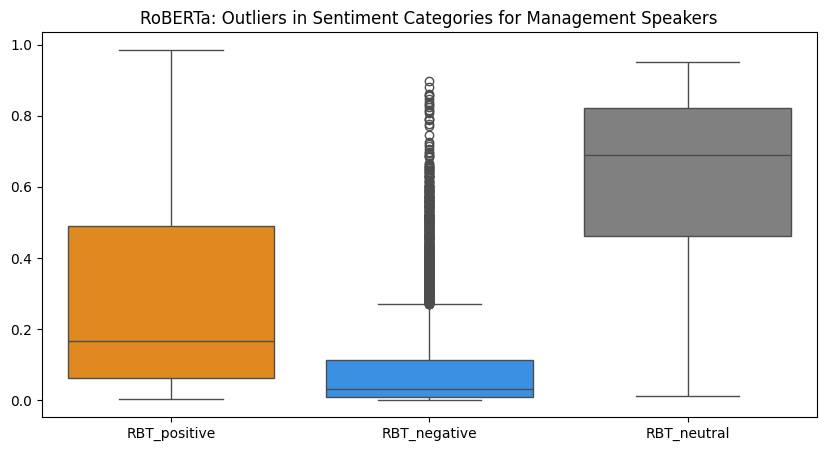

In [54]:
# Look for outliers in sentiments categories of data where speaker_role = "management"
# Display as vertical boxes on the same plot
management_data = data[data['speaker_role'] == 'management']
plt.figure(figsize=(10, 5))
# Use RBT_ columns for the boxplot
sns.boxplot(data=management_data[['RBT_positive', 'RBT_negative', 'RBT_neutral']], palette=sentiment_palette)
plt.title("RoBERTa: Outliers in Sentiment Categories for Management Speakers")
plt.show()

## Calculate quarterly sentiment values (Management not Analyst)

In [55]:
# Create dataframe to calculate median and standard deviation of every sentiment every quarter (UBS)
RBT_sentiment_stats = data.groupby(["quarter", "RBT_main_sentiment", "speaker_role","section"]).agg(
    median_score=("RBT_main_sentiment_score", "median"),
    std_score=("RBT_main_sentiment_score", "std")
    # if NaN values, replace with 0
).fillna(0).reset_index()

# Drop rows where speaker_role = analyst
RBT_sentiment_stats = RBT_sentiment_stats[RBT_sentiment_stats['speaker_role'] != 'analyst']
RBT_sentiment_stats.head(10)   

,quarter,RBT_main_sentiment,speaker_role,section,median_score,std_score
1,2022-Q1,RBT_negative,management,prepared,0.542210,0.087941
2,2022-Q1,RBT_negative,management,qa,0.604435,0.064827
4,2022-Q1,RBT_neutral,management,prepared,0.701729,0.122710
5,2022-Q1,RBT_neutral,management,qa,0.766186,0.113091
6,2022-Q1,RBT_neutral,operator,qa,0.817172,0.048174
8,2022-Q1,RBT_positive,management,prepared,0.747497,0.110476
9,2022-Q1,RBT_positive,management,qa,0.753607,0.122689
11,2022-Q2,RBT_negative,management,prepared,0.622660,0.082034
12,2022-Q2,RBT_negative,management,qa,0.655931,0.113358
14,2022-Q2,RBT_neutral,management,prepared,0.778287,0.117806


In [56]:
# Calculate max and mean values for std_score for sentiments
RBT_sentiment_std_max = RBT_sentiment_stats.groupby('RBT_main_sentiment')['std_score'].max()
RBT_sentiment_std_mean = RBT_sentiment_stats.groupby('RBT_main_sentiment')['std_score'].mean()
print("Max std_score per sentiment:")
print(RBT_sentiment_std_max)
print("\nMean std_score per sentiment:")
print(RBT_sentiment_std_mean)

Max std_score per sentiment:
RBT_main_sentiment
RBT_negative    0.175277
RBT_neutral     0.127965
RBT_positive    0.155187
Name: std_score, dtype: float64

Mean std_score per sentiment:
RBT_main_sentiment
RBT_negative    0.069462
RBT_neutral     0.105896
RBT_positive    0.120138
Name: std_score, dtype: float64


## Differences between Prepared and Q&A sections

In [57]:
# Calculate differences between prepared and QA sentiment scores for management if NaN use zero
diff_RBT_sentiment_stats = RBT_sentiment_stats.pivot_table(index=['quarter', 'RBT_main_sentiment'], columns='section', values='median_score').reset_index()
diff_RBT_sentiment_stats = diff_RBT_sentiment_stats.fillna(0)
diff_RBT_sentiment_stats['diff'] = diff_RBT_sentiment_stats['qa'] - diff_RBT_sentiment_stats['prepared']

In [58]:
diff_RBT_sentiment_stats.head(10)

section,quarter,RBT_main_sentiment,prepared,qa,diff
0,2022-Q1,RBT_negative,0.542210,0.604435,0.062224
1,2022-Q1,RBT_neutral,0.701729,0.791679,0.089950
2,2022-Q1,RBT_positive,0.747497,0.753607,0.006111
3,2022-Q2,RBT_negative,0.622660,0.655931,0.033271
4,2022-Q2,RBT_neutral,0.778287,0.776426,-0.001861
5,2022-Q2,RBT_positive,0.722695,0.769091,0.046397
6,2022-Q3,RBT_negative,0.532187,0.685545,0.153357
7,2022-Q3,RBT_neutral,0.793578,0.752933,-0.040644
8,2022-Q3,RBT_positive,0.724473,0.737350,0.012877
9,2022-Q4,RBT_negative,0.519431,0.539101,0.019670


In [59]:
# Find max standard deviation from all emotions from sentiment_std_max values
all_RBT_sentiment_std_max = RBT_sentiment_std_max.max()
print("Value for error bars: ", all_RBT_sentiment_std_max)

Value for error bars:  0.17527721305568528


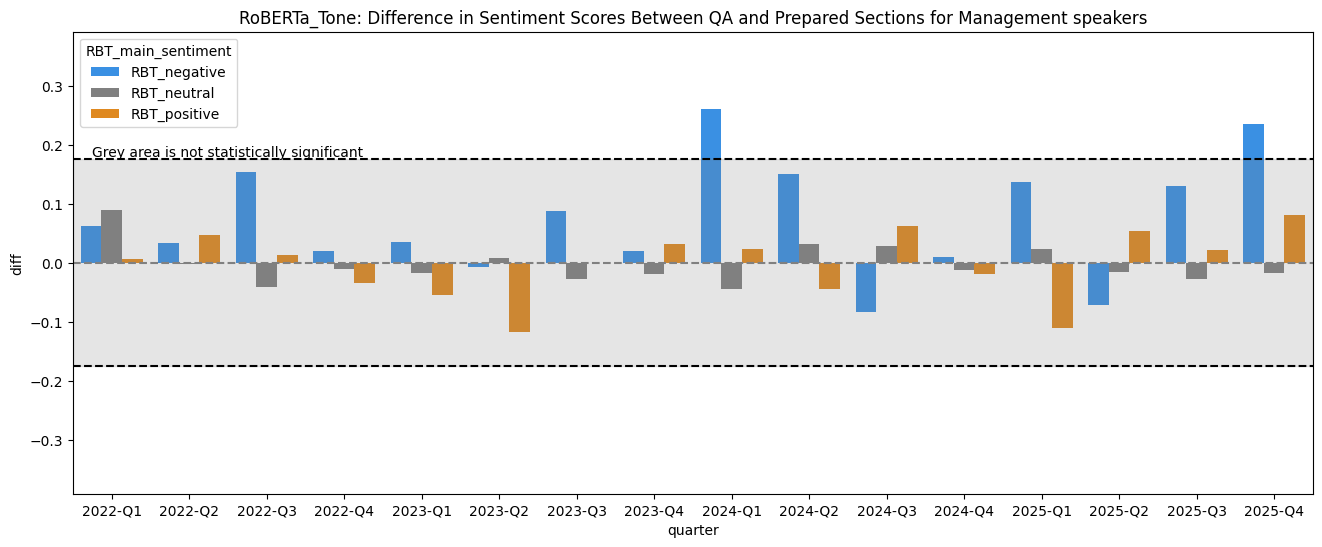

In [60]:
# Plot results as bar chart
plt.figure(figsize=(16, 6))
# fix y axis from 1.1 to -1.1
#plt.ylim(-1.1, 1.1)
sns.barplot(data=diff_RBT_sentiment_stats, x="quarter", y="diff", hue="RBT_main_sentiment", palette=sentiment_palette)

# Median scores are close to 1 in both sections, so the diff is tiny; zoom in to see it
diff_range = diff_RBT_sentiment_stats['diff'].abs().max() * 1.5
plt.ylim(-diff_range, diff_range)

plt.title("Difference in Sentiment Scores Between QA and Prepared Sections - Management (Excluding Analysts)")
plt.axhline(0, linestyle='--', color='gray')

# plot x-line at value of positive emotion standard deviation
plt.axhline(all_RBT_sentiment_std_max, linestyle='--', color='black')
plt.axhline(-all_RBT_sentiment_std_max, linestyle='--', color='black')
# infill area in grey across the whole x-axis
plt.axhspan(
    -all_RBT_sentiment_std_max,
    all_RBT_sentiment_std_max,
    color='grey',
    alpha=0.2
)

plt.title("RoBERTa_Tone: Difference in Sentiment Scores Between QA and Prepared Sections for Management speakers")

# Add text onto plot "Grey area represents ±1 standard deviation of positive emotion scores"
plt.text(
    x=1.5, 
    y=all_RBT_sentiment_std_max, 
    s="Grey area is not statistically significant", 
    color='black', 
    ha='center', 
    va='bottom'
)

# Save figure with bank name
plt.savefig(f"RoBERTa-Tone_sentiment_differences_{bank_name}.png")

# Compare RoBERTa and BERT-Emotion

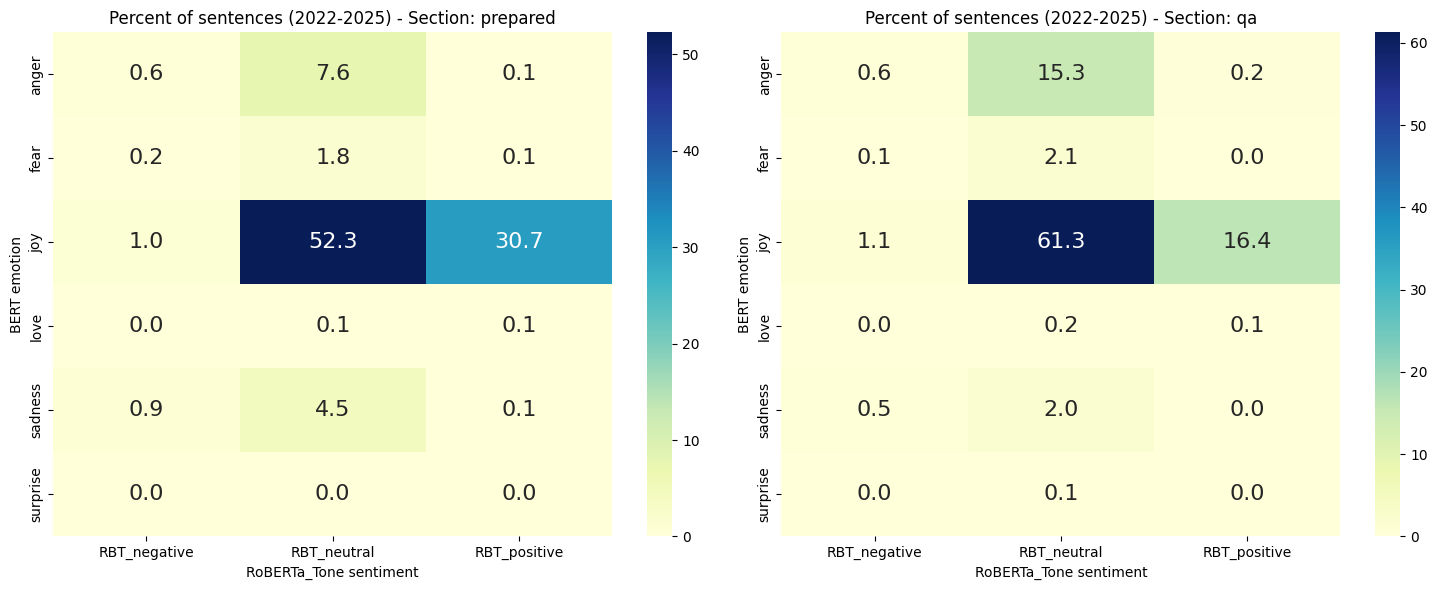

In [61]:
# Create two heatmaps side by side with speaker_role = management but split by section

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Display values as % of total number in large font
sections = data['section'].unique()
for i, section in enumerate(sections[:2]):  # Only take the first two sections for side by side comparison
    heatmap_data = pd.crosstab(
        data.loc[(data['speaker_role'] == 'management') & (data['section'] == section), 'main_emotion'],
        data.loc[(data['speaker_role'] == 'management') & (data['section'] == section), 'RBT_main_sentiment']
    )
    heatmap_data = heatmap_data / heatmap_data.values.sum() * 100  # Convert to percentage
    sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap="YlGnBu", ax=axes[i], annot_kws={"size": 16})
    axes[i].set_xlabel('RoBERTa_Tone sentiment')
    axes[i].set_ylabel('BERT emotion')
    axes[i].set_title(f'Percent of sentences (2022-2025) - Section: {section}')

plt.tight_layout()

# Save each subplot as its own image using its extent, plus the combined figure
for i, section in enumerate(sections[:2]):
    extent = axes[i].get_tightbbox(fig.canvas.get_renderer()).transformed(fig.dpi_scale_trans.inverted())
fig.savefig(f'BERT_emotion_vs_RoBERTa_Tone_{bank_name}.png')
plt.show()

# Save Output

In [62]:
# Save output as csv file with bank name in title
output_file = f"sentiment_classification_output_{bank_name}.csv"
data.to_csv(output_file, index=False)
print(f"Output saved to {output_file}")

Output saved to sentiment_classification_output_UBS.csv


# Apply BERTopic to sentences classified as "Negative" by FinBERT

## Sentences where FinBERT = Negative

In [63]:
# Create dataframe with sentences and speakers and quarters but only where main_sentiment = negative

negative_sentences = data[data['main_sentiment'] == 'negative'][['quarter','speaker_name', 'speaker_role','sentence', 'cleaned_text', 'main_sentiment','main_sentiment_score']]
negative_sentences = negative_sentences.sort_values(by=['quarter', 'speaker_role'])

negative_sentences.head(4)

,quarter,speaker_name,speaker_role,sentence,cleaned_text,main_sentiment,main_sentiment_score
10317,2022-Q1,Amit Goel,analyst,So what you're seeing there and whether the ma...,"[youre, seeing, whether, margin, stable, stead...",negative,0.562937
10361,2022-Q1,Adam Terelak,analyst,I think that's the level when in previous cycl...,"[think, thats, level, previous, cycle, saw, bi...",negative,0.913481
10430,2022-Q1,Flora Bocahut,analyst,And how much of this do you think could be rev...,"[much, think, could, reversed, coming, quarter...",negative,0.732441
10431,2022-Q1,Flora Bocahut,analyst,The second question is regarding the client be...,"[second, question, regarding, client, behavior...",negative,0.837717


## BERTopic Analysis using function to apply to any year

In [64]:
import ast
from bertopic import BERTopic
from umap import UMAP

# Not sure what ast and UMAP actually do !
# ast is used to safely evaluate strings containing Python literals (like lists) into actual Python objects.
# UMAP is a dimensionality reduction technique often used to preprocess data for clustering or topic modeling.

def plot_negative_topics_for_year(data, year, bank=bank_name, min_topic_size=10, top_n_words=3):
    """Run BERTopic on a year's negative sentences and plot topic counts as a bar chart.

    Returns (topic_model, topic_info), or (None, None) if no topics were found.
    """
    year = str(year)
    quarters = [f"{year}-Q{q}" for q in range(1, 5)]

    # Negative sentences for the year
    yr_data = data[(data["main_sentiment"] == "negative") & (data["quarter"].isin(quarters))]

    # Adapt text from "strings of lists" format in csv file, dropping empty sentences
    #texts = [" ".join(ast.literal_eval(t)) for t in yr_data["cleaned_text"]]
    texts = [" ".join(tokens) for tokens in yr_data["cleaned_text"]]
    texts = [t for t in texts if t.strip() != ""]
    print(f"Number of negative sentences for BERTopic modelling in {year}: {len(texts)}")

    topic_model = BERTopic(
        umap_model=UMAP(random_state=42, n_jobs=1),
        min_topic_size=min_topic_size,
        calculate_probabilities=False,
    )
    topic_model.fit_transform(texts)
    topic_info = topic_model.get_topic_info()

    plot_info = topic_info[topic_info["Topic"] != -1].sort_values("Count")  # drop the outlier "topic"
    if plot_info.empty:
        print(f"No topics found for {year} (only outliers); try a smaller min_topic_size.")
        return None, topic_info

    # Shorten names like "0_rates_margin_nii_cost" to "rates, margin, nii"
    labels = [", ".join(name.split("_")[1:1 + top_n_words]) for name in plot_info["Name"]]

    fig, ax = plt.subplots(figsize=(10, 0.45 * len(plot_info) + 1.5))
    bars = ax.barh(labels, plot_info["Count"], color="steelblue")
    ax.bar_label(bars, padding=3)
    ax.set_xlabel("Number of negative sentences")
    ax.set_title(f"{bank} negative sentences by BERTopic topic for year = {year}")
    plt.tight_layout()
    plt.show()
    return topic_model, topic_info

Number of negative sentences for BERTopic modelling in 2022: 153


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 7729.29it/s]


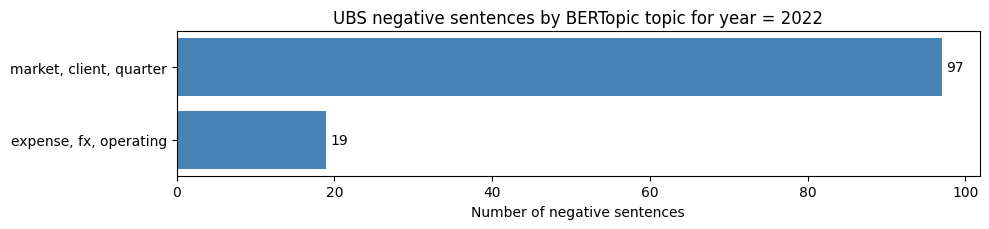

Number of negative sentences for BERTopic modelling in 2023: 227


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 14724.88it/s]


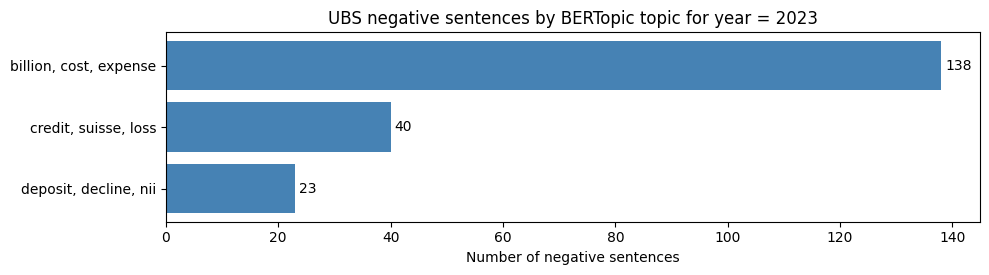

Number of negative sentences for BERTopic modelling in 2024: 212


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 11867.85it/s]


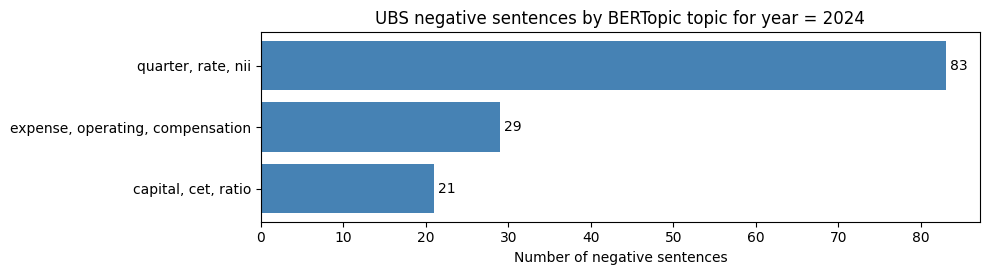

Number of negative sentences for BERTopic modelling in 2025: 172


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 12208.25it/s]


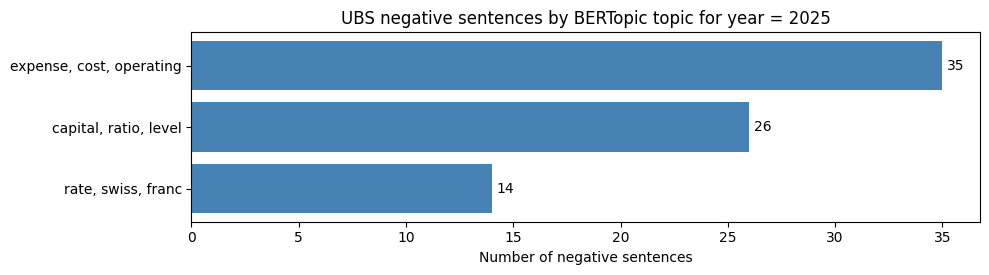

In [65]:
YR_topic_model_22, YR_topic_info_22 = plot_negative_topics_for_year(data, "2022")
YR_topic_model_23, YR_topic_info_23 = plot_negative_topics_for_year(data, "2023")
YR_topic_model_24, YR_topic_info_24 = plot_negative_topics_for_year(data, "2024")
YR_topic_model_25, YR_topic_info_25 = plot_negative_topics_for_year(data, "2025")


In [66]:
# Collect yr_topic_info for all years into one dataframe for plotting, include year as a column
all_YR_topic_info = pd.concat([
    YR_topic_info_22.assign(year="2022"),
    YR_topic_info_23.assign(year="2023"),
    YR_topic_info_24.assign(year="2024"),
    YR_topic_info_25.assign(year="2025")
])
all_YR_topic_info.reset_index(drop=True, inplace=True)

In [67]:
# Add new column for plotting as legend to all_YR_topic_info
# remove numbers and replace underscores with commas
all_YR_topic_info["Legend"] = all_YR_topic_info["Name"].apply(
    lambda x: ", ".join(x.split("_")[1:])
)
all_YR_topic_info.head()


,Topic,Count,Name,Representation,Representative_Docs,year,Legend
0,-1,37,-1_million_loss_credit_pressure,"[million, loss, credit, pressure, net, cost, q...","[net credit loss expense million, credit loss ...",2022,"million, loss, credit, pressure"
1,0,97,0_market_client_quarter_also,"[market, client, quarter, also, lower, revenue...",[let start fourth quarter revenue slide additi...,2022,"market, client, quarter, also"
2,1,19,1_expense_fx_operating_compensation,"[expense, fx, operating, compensation, exlitig...",[operating expense exlitigation fx flat versus...,2022,"expense, fx, operating, compensation"
3,-1,26,-1_quarter_capital_cet_third,"[quarter, capital, cet, third, million, six, l...",[regarding swiss national bank recently announ...,2023,"quarter, capital, cet, third"
4,0,138,0_billion_cost_expense_revenue,"[billion, cost, expense, revenue, quarter, low...",[underlying operating expense roughly unchange...,2023,"billion, cost, expense, revenue"


## BERTopic - final plot

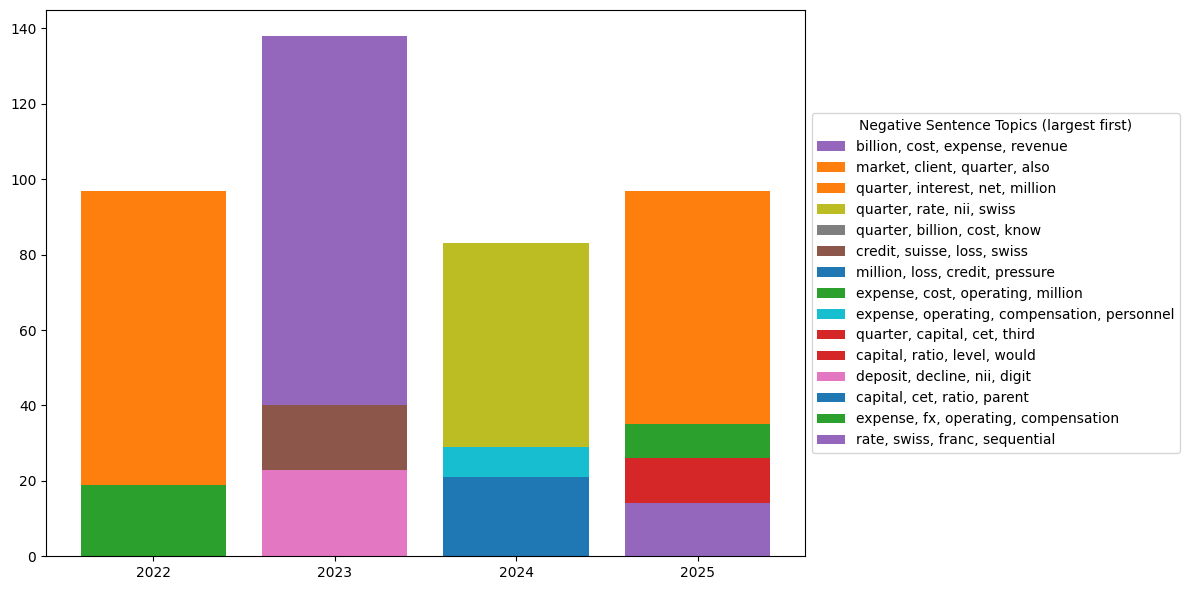

In [68]:

fig, ax = plt.subplots(figsize=(12, 6))

for topic in all_YR_topic_info["Name"].unique():
    topic_data = all_YR_topic_info[all_YR_topic_info["Name"] == topic]
    ax.bar(topic_data["year"], topic_data["Count"], label=topic_data["Legend"].iloc[0])

# Total count per legend label, used for ordering
totals = all_YR_topic_info.groupby("Legend")["Count"].sum()

handles, labels = ax.get_legend_handles_labels()
order = sorted(range(len(labels)), key=lambda i: totals[labels[i]], reverse=True)

ax.legend(
    [handles[i] for i in order],
    [labels[i] for i in order],
    loc="center left",
    bbox_to_anchor=(1, 0.5),   # legend at the side
    title="Negative Sentence Topics (largest first)",
)
plt.tight_layout()
plt.savefig(f"negative_sentence_topics_by_year_for_{bank_name}.png")
plt.show()

# Check run times

In [69]:
# End timer and print elapsed time in minutes to 2 significant figures
end_time = time.time()
print("Elapsed time: ", round((end_time - start_time)/60, 2), "minutes")

Elapsed time:  6.22 minutes
